In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
from make import load_secondary_data, load_heath_assessment_test_data

all_spectrograms, all_labels = load_secondary_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [4]:
valid_spec, valid_labels = load_heath_assessment_test_data()

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 

In [5]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [6]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def get_x(i : int):
        arr = all_spectrograms[i]

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr.shape) == 3:
                arr = np.mean(arr, axis=-1)  # average across channels
        
        #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return all_labels[i]

In [7]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [8]:
items = list(range(len(all_spectrograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

In [9]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

In [10]:
learner = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)

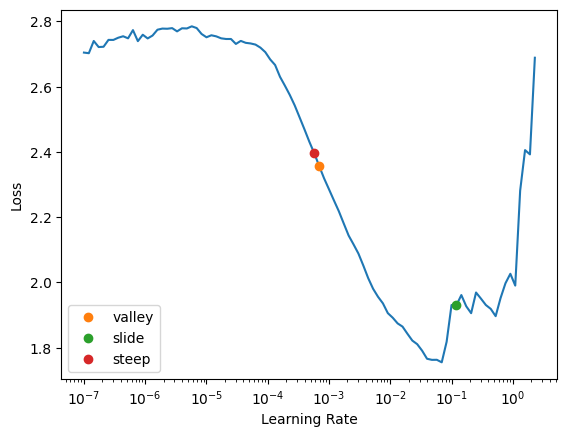

In [11]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [12]:
learner.fit_one_cycle(30, lr.valley)

epoch,train_loss,valid_loss,accuracy,time
0,2.078113,1.718861,0.341667,00:00
1,1.476547,1.112826,0.375000,00:00
2,1.156042,0.969133,0.508333,00:00
3,0.907677,0.858914,0.575000,00:00
4,0.664104,0.724628,0.675000,00:00
5,0.450614,0.633465,0.733333,00:00
6,0.267539,0.561998,0.775000,00:00
7,0.152834,0.550866,0.758333,00:00
8,0.085869,0.520777,0.775000,00:00
9,0.049220,0.511053,0.775000,00:00


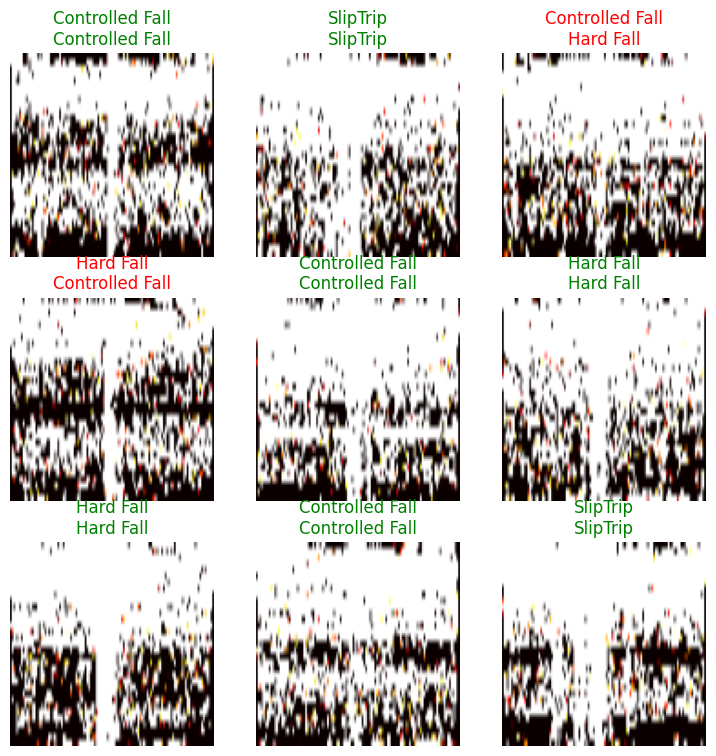

In [13]:
learner.show_results()

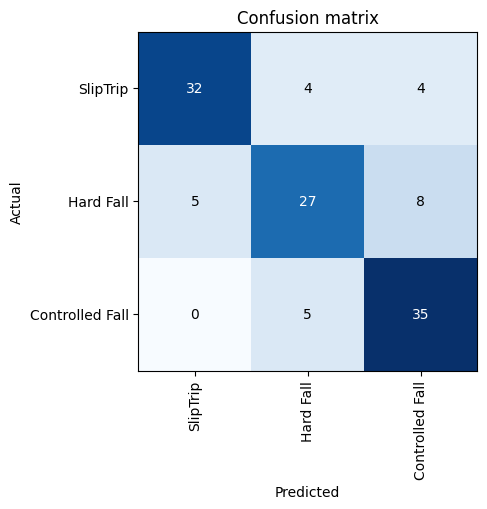

In [16]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [11]:
dir = Path('./models')

In [12]:
learner = load_learner(dir/'classic_cnn.pkl')

/media/Delta/code/Master/Master-project/vibration_model/.venv/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [ ]:
learner.path = dir

learner.export('classic_cnn.pkl')

In [13]:
def get_x_test(i):
    arr = valid_spec[i]

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr.shape) == 3:
        arr = np.mean(arr, axis=-1)  # average across channels
    
    #arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('hot')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [14]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [16]:
len(valid_spec)

204

In [17]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [22]:
learner.validate()

(#2) [0.5519068837165833,0.7833333611488342]

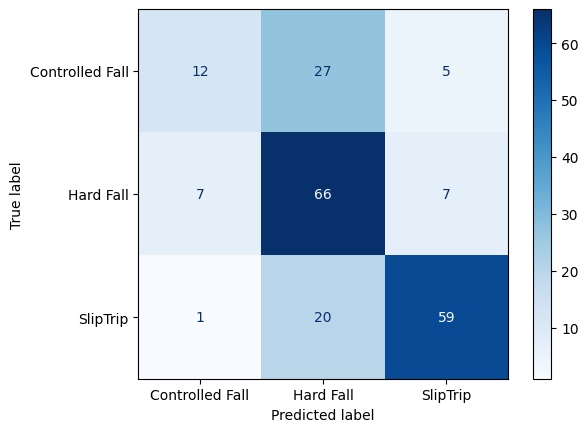

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dls.vocab)
disp.plot(cmap="Blues")  # customize as you like
plt.show()

In [19]:
accuracy_score(y_test, y_pred)

0.6715686274509803

In [20]:
precision_score(y_test, y_pred, average='weighted')

0.6843359654718176

In [21]:
recall_score(y_test, y_pred, average="weighted")

0.6715686274509803

In [22]:
f1_score(y_test, y_pred, average="weighted")

0.6555469715594435